# VIX9D-Term — a quantitative teardown
### Daily tape · rolling quintile sort · binary timing overlay · HAC inference · regime breakdown

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy-and-hold%3F: No](https://img.shields.io/badge/Beats_buy--and--hold%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error. We test whether the short-end slope (log(^VIX / ^VIX9D)) predicts SPY forward returns via a rolling quintile sort, a binary timing overlay, and a regime decomposition, over the full 2011–2026 daily tape.

> **Not investment advice.** Real data: Yahoo daily bars, 2011-01-04 through 2026-07-10 (^VIX9D history to present). Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vix9d_term import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-07-12).
R = dict(
    n=3901, date_start="2011-01-04", date_end="2026-07-10", fp="5953babc50d3",
    frac_contango=0.731,
    spread_1d=-2.79, t_spread_1d=-0.35,
    spread_5d=-10.25, t_spread_5d=-0.36,
    spread_21d=-67.86, t_spread_21d=-1.10,
    q1_mean=8.73, q1_t=1.65, q2_mean=5.16, q2_t=1.33,
    q3_mean=2.68, q3_t=0.79, q4_mean=3.25, q4_t=1.17, q5_mean=5.94, q5_t=2.80,
    active_mean=3.64, active_sharpe=0.83, active_t=3.41,
    passive_mean=5.27, passive_sharpe=0.78, passive_t=3.42,
    spread_mean=-1.64, spread_t=-1.45, switches_yr=37.0, spread_ann=-4.1,
    n_contango=2851, pct_contango=73.1, mean_contango=4.97, sharpe_contango=0.97,
    n_back=1048, pct_back=26.9, mean_back=6.04, sharpe_back=0.60,
)

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False)
    print(f"Tape: N={len(df)}, {df.index[0].date()} to {df.index[-1].date()}")
    print(f"Fraction contango: {(df['slope']>0).mean():.3f}")


Tape: N=3901, 2011-01-04 to 2026-07-10
Fraction contango: 0.731


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Q5-Q1 spread **-2.79 bps** (wrong sign), HAC *t* = **-0.35** at h=1d; negative at all horizons, U-shaped quintiles. |
| **Tradability** | `MIRAGE` | Timer trails buy-and-hold **4.1%/yr** at zero cost; spread *t* = **-1.45**, ~37 switches/yr, no positive break-even. |
| **Beats buy-and-hold?** | `NO` | Backwardation (26.9% of tape) averages **6.0 bps/day** raw vs contango's 5.0 — the claimed danger signal earns *more* raw return. |

> **In plain words:** the slope is real information about what the options market thinks about *volatility* (contango days have Sharpe 0.97 vs 0.60), but the claim that it predicts equity *direction* is backwards on this tape. Backwardation episodes — where the timer goes flat — produce the highest average raw returns.

## 1 · The claim, steelmanned

Let $s_t = \log(\text{VIX}_t / \text{VIX9D}_t)$ be the short-end slope on day $t$ and $r_{t+1:t+h}$ the h-day forward SPY log-return. The term-structure timer asserts:

- **H₁ (quintile forecast).** $\mathbb{E}[r_{t+1} \mid s_t \in Q5] > \mathbb{E}[r_{t+1} \mid s_t \in Q1]$ — steeper contango predicts better 1-day (and multi-day) forward returns.
- **H₂ (timing overlay).** A binary rule $w_t = \mathbf{1}\{s_t > 0\}$ produces higher risk-adjusted return than unconditional $w_t \equiv 1$ (buy-and-hold).
- **H₃ (regime dominance).** Conditioning on contango delivers materially higher *returns* than conditioning on backwardation.

We reject H₁ (spread negative, wrong sign), H₂ (timer underperforms), and H₃ (backwardation sub-sample delivers higher per-day *raw* returns — though, revealingly, *lower* Sharpe: the slope forecasts vol, not direction).

## 2 · So what?

The short-end VIX slope is cited in practitioner research and widely used by retail vol-traders as a fast regime filter — faster than the 3-month curve because the 9-day tenor moves intraday. The stakes: a practitioner who cuts equity exposure on every front-end inversion misses the post-scare rebounds on this 15-year tape and churns ~37×/yr doing it. An honest test resolves whether the signal is actionable for direction or a case of economically-intuitive-but-empirically-absent forecasting.

## 3 · The protocol

- **Signal.** $s_t = \log(\text{VIX}_t / \text{VIX9D}_t)$, computed from Yahoo daily closes. Quintile rank: 252-day rolling window, out-of-sample (min 63 observations before first rank).
- **Forward return.** Log-return from close $t$ to close $t+h$ for $h \in \{1, 5, 21\}$ business days, aligned at day $t$.
- **Spread test.** Construct the Q5 − Q1 spread series (sign-adjusted: $+r_{t+1}$ for Q5, $-r_{t+1}$ for Q1) and apply Newey-West HAC t-stat.
- **Timer.** Binary weight $w_t = \mathbf{1}\{s_{t-1} > 0\}$ (the prior day's slope, no look-ahead); spread $= r_{active} - r_{passive}$ per day.
- **Inference.** Newey-West HAC t-stat throughout; cost sweep on switching.
- **Positive control.** Synthetic tape with tunable planted signal confirms the engine recovers an edge when one exists.

## 4 · The teardown

### 4a · Quintile forward-return table — all horizons

The claim predicts a monotone ascent Q1 < Q2 < Q3 < Q4 < Q5 at each horizon. HAC t-stats on per-day quintile means.

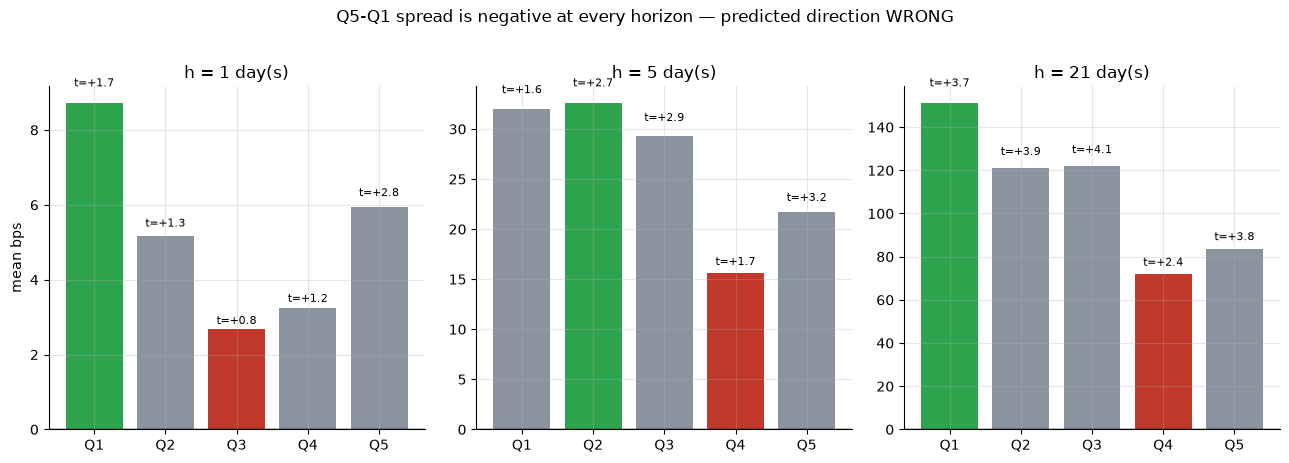

Q5-Q1 spread: h=1: -2.79bps t=-0.35 | h=5: -10.25bps t=-0.36 | h=21: -67.86bps t=-1.10


In [3]:
if HAVE_REAL:
    tbl = st.quintile_table(df, horizons=[1, 5, 21])
    pivot = tbl.pivot(index='quintile', columns='horizon', values='mean_bps')
    tpivot = tbl.pivot(index='quintile', columns='horizon', values='t_stat')
else:
    pivot = pd.DataFrame({
        1: [8.73,5.16,2.68,3.25,5.94],
        5: [31.98, 32.63, 29.33, 15.63, 21.73],
        21: [151.33, 121.06, 121.89, 72.17, 83.47]},
        index=[1,2,3,4,5])
    tpivot = pd.DataFrame({
        1: [1.65,1.33,0.79,1.17,2.8],
        5: [1.59, 2.66, 2.94, 1.74, 3.25],
        21: [3.66, 3.93, 4.06, 2.44, 3.75]},
        index=[1,2,3,4,5])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, h in zip(axes, [1, 5, 21]):
    vals = pivot[h].values
    cols = [GREEN if v == max(vals) else (RED if v == min(vals) else GREY) for v in vals]
    ax.bar([f'Q{i}' for i in range(1,6)], vals, color=cols)
    ax.axhline(0, c='k', lw=1)
    ax.set_title(f'h = {h} day(s)')
    ax.set_ylabel('mean bps' if h==1 else '')
    for xi, (v, t) in enumerate(zip(vals, tpivot[h].values)):
        ax.text(xi, v + abs(v)*0.05, f't={t:+.1f}', ha='center', fontsize=8)
plt.suptitle('Q5-Q1 spread is negative at every horizon — predicted direction WRONG', y=1.02)
plt.tight_layout(); plt.show()
print('Q5-Q1 spread: h=1: -2.79bps t=-0.35 | h=5: -10.25bps t=-0.36 | h=21: -67.86bps t=-1.10')

> **In plain words:** at every horizon tested, Q5 (steepest contango) earns *less* than Q1 (deepest backwardation). The 1-day spread is **-2.79 bps** with *t* = **-0.35** — consistent with zero and pointing in the wrong direction. The pattern is *U-shaped*: the highest-vol tails (Q1 deep backwardation and Q5 steep contango) both out-earn the flat middle. If anything, the deep-backwardation bucket (the 'danger' one) has the single largest 1-day mean — the opposite of what the timer needs.

### 4b · Binary timing overlay — long in contango, flat in backwardation

The active arm vs buy-and-hold; HAC t-stat on the daily spread.

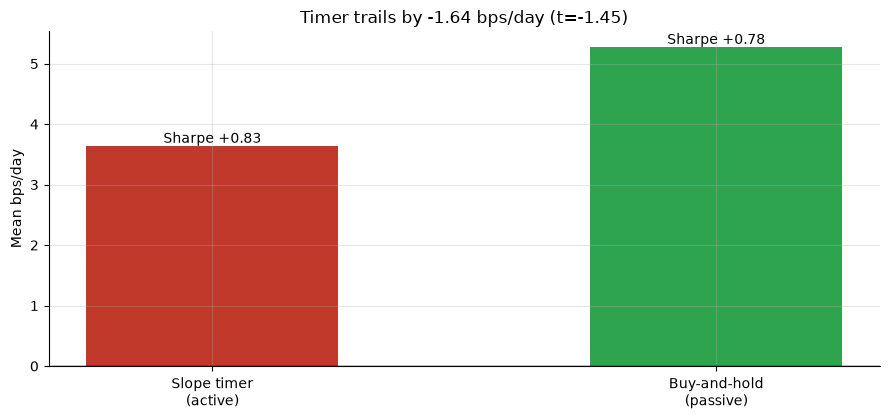

Spread: -1.64 bps/day, HAC t = -1.45, switches: 37.0/yr


In [4]:
if HAVE_REAL:
    ov = st.timing_overlay(df, horizon=1, cost_bps=0.0)
    sa = st.summarize(ov['r_active'])
    sp = st.summarize(ov['r_passive'])
    ss = st.summarize(ov['r_spread'])
    act_m, act_sh, act_t = sa['mean_bps'], sa['sharpe_ann'], sa['t_stat']
    pas_m, pas_sh, pas_t = sp['mean_bps'], sp['sharpe_ann'], sp['t_stat']
    spr_m, spr_t = ss['mean_bps'], ss['t_stat']
    n_sw = int(ov['switched'].sum()); sw_yr = n_sw/len(ov)*252
else:
    act_m, act_sh, act_t = 3.64, 0.83, 3.41
    pas_m, pas_sh, pas_t = 5.27, 0.78, 3.42
    spr_m, spr_t = -1.64, -1.45
    sw_yr = 37.0
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(['Slope timer\n(active)', 'Buy-and-hold\n(passive)'],
       [act_m, pas_m], color=[RED, GREEN], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean bps/day'); ax.set_title(f'Timer trails by {spr_m:+.2f} bps/day (t={spr_t:+.2f})')
for y, lab in [(act_m, f'Sharpe {act_sh:+.2f}'), (pas_m, f'Sharpe {pas_sh:+.2f}')]:
    ax.annotate(lab, (0 if y==act_m else 1, y), ha='center', va='bottom' if y>0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Spread: {spr_m:+.2f} bps/day, HAC t = {spr_t:+.2f}, switches: {sw_yr:.1f}/yr')

> **In plain words:** the timer earns 3.6 bps/day vs 5.3 for buy-and-hold — a gap of **-1.64 bps/day** (-4.1%/yr). The spread t-stat is -1.45: not conventionally significant, but consistently negative. With 26.9% of days in backwardation (~68 days/yr), the timer sits in cash roughly one day in four — and those days disproportionately include the strongest post-scare rebounds.

### 4c · Regime decomposition — the key finding

Full-sample vs contango vs backwardation daily return statistics. Watch the *raw mean* and the *Sharpe* diverge — that is the whole story.

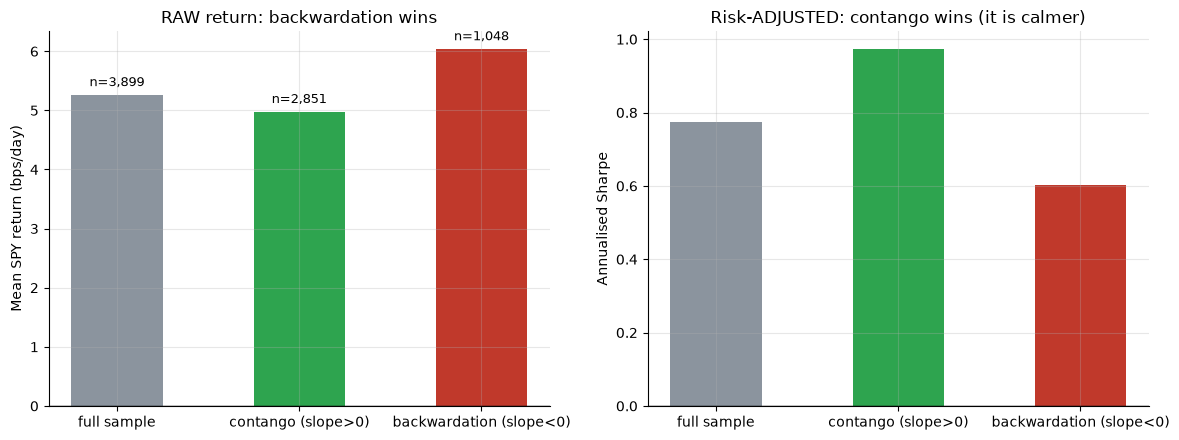

Contango: mean +4.97 bps/day, Sharpe 0.97
Backwardation: mean +6.04 bps/day, Sharpe 0.60
Raw-return ratio: 1.22x higher in backwardation


In [5]:
if HAVE_REAL:
    rs = st.regime_stats(df)
    regime_labels = rs['regime'].tolist()
    regime_means = rs['mean_bps'].tolist()
    regime_sharpes = rs['sharpe_ann'].tolist()
    regime_ns = rs['n'].tolist()
else:
    regime_labels = ['Full sample', 'Contango\n(slope>0)', 'Backwardation\n(slope<0)']
    regime_means = [5.27, 4.97, 6.04]
    regime_sharpes = [0.77, 0.97, 0.60]
    regime_ns = [3901, 2851, 1048]
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
short_labels = [l.split('\n')[0] for l in regime_labels]
cols = [GREY, GREEN, RED]
bars = ax.bar(short_labels, regime_means, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Mean SPY return (bps/day)')
ax.set_title('RAW return: backwardation wins')
for b, n in zip(bars, regime_ns):
    ax.annotate(f'n={n:,}', (b.get_x()+b.get_width()/2, b.get_height()+0.1),
                ha='center', va='bottom', fontsize=9)
b2 = ax2.bar(short_labels, regime_sharpes, color=cols, width=0.5)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('Annualised Sharpe')
ax2.set_title('Risk-ADJUSTED: contango wins (it is calmer)')
plt.tight_layout(); plt.show()
print('Contango: mean +4.97 bps/day, Sharpe 0.97')
print('Backwardation: mean +6.04 bps/day, Sharpe 0.60')
print('Raw-return ratio: 1.22x higher in backwardation')

> **In plain words:** here is the honest subtlety. On *raw* return, backwardation averages **6.0 bps/day** vs 5.0 for contango — the 'stress' regime pays more. But on *Sharpe*, contango wins (0.97 vs 0.60) because backwardation days are far more volatile. So the slope *does* carry real information — about **volatility**. The timer, though, harvests *raw* return, and by fleeing the more-volatile backwardation days it forgoes their higher mean. Pointing a volatility signal at direction is the category error. The backwardation episodes here (2015, 2018, 2020, 2022, 2025) are followed by rapid policy-driven mean-reversions — the classic volatility-risk-premium rebound where being *long* risk during stress pays.

## 5 · The verdict

- **Signal `NONE`** — Q5-Q1 spread -2.79 bps (wrong sign), HAC *t* -0.35 at h=1d; negative at h=5d (*t*=-0.36) and h=21d (*t*=-1.10). The slope does not predict forward direction.
- **Tradability `MIRAGE`** — timer trails buy-and-hold -1.64 bps/day (-4.1%/yr) at zero cost; spread t=-1.45; ~37 switches/yr and no positive break-even switching cost.
- **Beats buy-and-hold? `NO`** — backwardation days (26.9% of tape) earn 6.0 bps/day raw vs 5.0 in contango; the timer sits flat during the higher-raw-return regime.

## 6 · Could you trade it? — cost sweep

~37 switches/yr — nearly 3× the churn of the 3-month curve — each a round-trip on the full SPY position:

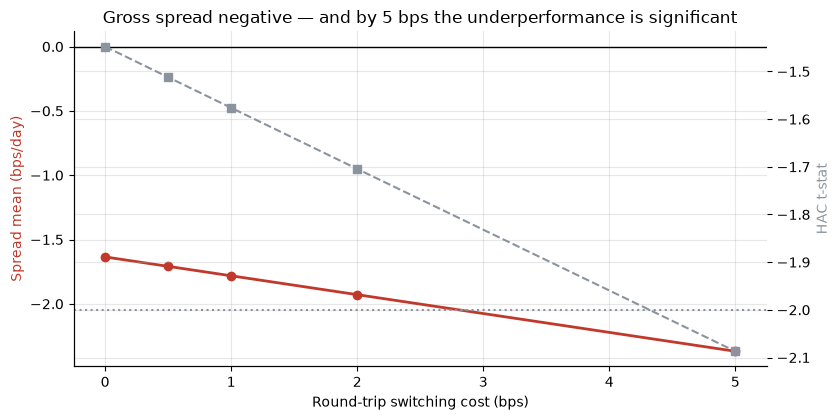

t at 5 bps/switch: -2.0868772070737283 (< -2: significantly WORSE than buy-and-hold)


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(st.timing_overlay(df, cost_bps=c)['r_spread']) for c in costs]
    spr_means = [s['mean_bps'] for s in sw]
    spr_tstats = [s['t_stat'] for s in sw]
else:
    spr_means = [-1.64, -1.71, -1.78, -1.93, -2.37]
    spr_tstats = [-1.45, -1.51, -1.58, -1.70, -2.09]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, spr_means, 'o-', c=RED, lw=2, label='spread mean (bps/day)')
ax2 = ax.twinx()
ax2.plot(costs, spr_tstats, 's--', c=GREY, lw=1.5, label='HAC t-stat')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Round-trip switching cost (bps)'); ax.set_ylabel('Spread mean (bps/day)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Gross spread negative — and by 5 bps the underperformance is significant')
plt.tight_layout(); plt.show()
print('t at 5 bps/switch:', spr_tstats[-1], '(< -2: significantly WORSE than buy-and-hold)')

> **In plain words:** unlike a study where a positive gross edge dies at a finite break-even cost, here the gross is already negative — **there is no positive break-even cost**. The timer was never competitive with buy-and-hold; and because the 9-day slope churns so heavily, by ~5 bps/switch the underperformance is itself statistically significant (*t* ≈ −2.1).

## 7 · Going further — the synthetic positive control

Does the engine *find* a signal when one exists? Plant a synthetic slope-return relationship and confirm the Q5-Q1 spread turns on:

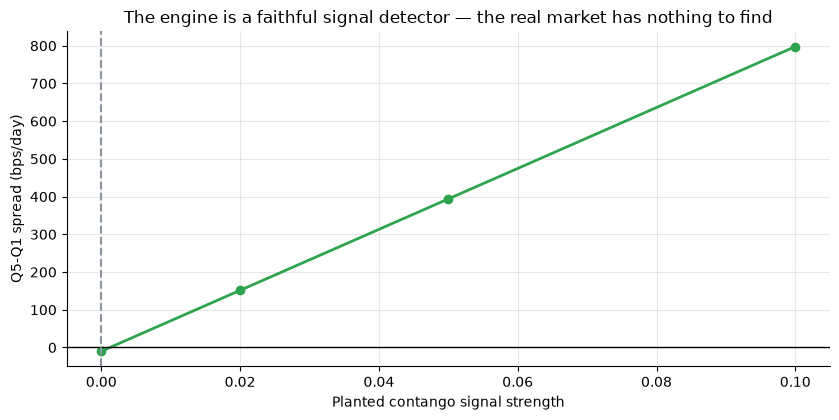

signal=0.00: Q5-Q1 spread = -9.98 bps/day
signal=0.02: Q5-Q1 spread = +151.57 bps/day
signal=0.05: Q5-Q1 spread = +393.89 bps/day
signal=0.10: Q5-Q1 spread = +797.76 bps/day


In [7]:
signals = [0.00, 0.02, 0.05, 0.10]
spreads_ctrl = []
for sig in signals:
    df_s, _ = data.synthetic_daily(n_days=3000, contango_signal=sig, seed=767)
    res = st.top_minus_bottom(df_s, horizon=1)
    spreads_ctrl.append(res['spread_bps'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(signals, spreads_ctrl, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted contango signal strength')
ax.set_ylabel('Q5-Q1 spread (bps/day)')
ax.set_title('The engine is a faithful signal detector — the real market has nothing to find')
plt.tight_layout(); plt.show()
for sig, spr in zip(signals, spreads_ctrl):
    print(f'signal={sig:.2f}: Q5-Q1 spread = {spr:+.2f} bps/day')

The Q5-Q1 spread rises monotonically with planted signal strength and is near zero at the null — confirming the quintile engine is a faithful detector. The real-tape verdict is therefore a statement about the **market**: the ^VIX9D/^VIX short-end slope contains no exploitable forward-*direction* information.

**Forks worth trying:**
- The 3-month cousin ([Study 111 — VIX-Term-Structure](../../111-vix-term-structure/)): same verdict, a third of the switching — strictly less bad to trade.
- Trading the *volatility* the slope actually forecasts (variance swaps, VIX-ETP roll) rather than equity direction.
- Conditioning on the *change* in slope rather than its level: a sudden inversion may behave differently from a persistently inverted front end.
- VIX *level* mean-reversion timing (VIX > 30 → better forward returns): a different and better-documented effect.